# Sprint S4 : Segmentation clients : RFM + K-Means 

## SmartShop_ML - PFE : *Système intelligent d'aide à la décision pour le e-commerce*

### Contexte
Dans les plateformes e-commerce, la personnalisation joue un rôle clé dans l'amélioration de l'expérience utilisateur et l'augmentation des ventes.

### Objectif
Segmenter les clients en groupes homogènes à partir de leur comportement d'achat, en utitlisant la méthodologie **RFM** (Reecency, Frequency, Monetary) et l'algorithme **K-Means**.

### Méthodologie RFM

| Dimension | Définition | Interprétation |
|--------|--------|------|
| **R - Recency** | Jours depuis la dernière commande | Petit = client récent → précieux |
|**F - Frequency**  | Nombre total de commandes | Grand = client fidèle |
| **M - Monetary** | Montant totat dépensé | Grand = forte valeur client |


**Principe** : Un bon client achète *récemment*, *souvent* et *beacoup*.
La RFM qualifie ces 3 comportements et le K-Means regroupe ceux similaires.

---

### Plan du travail

- [ 1 - Imports & Configuration ](#1)
- [ 2 - Chargement du dataset ](#2)
- [ 3 - Analyse exploratoire & Pré-traitement ](#3)
- [ 4 - Calcul des scores RFM ](#4)
- [ 5 - Normalisation & préparation pour K-Means ](#5)
- [ 6 - Selection du K optimal — méthode Coude + Silhouette ](#6)
- [ 7 - Entraînement k-Means ](#7)
- [ 8 - Analyse & visualisation des clusters](#8)
- [ 9 - Insights métier & Actions CRM](#9)
- [ 10 - Sauvegarde des artefacts ML (.pkl)](#10)

---

### Références clés
- Dataset d'apprentissage : Brazilian E-Commerce (Olist) — Kaggle

<a name="1"></a>
## 1 - Imports & Configuration

In [1]:
# ===== Librairies standard ===================================================
import os
import warnings
import json
from pathlib import Path
from datetime import datetime, timedelta

warnings.filterwarnings('ignore')

# ===== Données & calcul ===================================================
import pandas as pd
import numpy as np
import random

# ===== Visualisation ===================================================
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image

# ===== Machine Learning  ===================================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import joblib

# ==== Style plots =====================================================
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
})
sns.set_palette("Set2")
PALETTE = ["#6366F1", "#10B981", "#F59E0B", "#EF4444"]

# ==== Seed reproductibilité =====================================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Imports chargés")

Imports chargés


In [2]:
# SOURCE DE DONNÉES — SmartShop (réel) ou Olist Brasil (Kaggle fallback) 
#
# SmartShop : rfm.csv  déjà calculé par seed_smartshop.py
#   colonnes : user_id, email, recency_days, frequency, monetary, avg_order_value, segment
#
# Kaggle (fallback) : Olist Brazilian E-Commerce
#   on calcule R/F/M depuis olist_orders + olist_order_payments
#
# Après harmonisation, df_rfm_raw contient :
#   customer_id  → str identifiant client
#   recency      → jours depuis dernier achat (int)
#   frequency    → nb commandes (int)
#   monetary     → CA total (float)

import os
from pathlib import Path
import pandas as pd
import numpy as np

SMARTSHOP_DIR = Path("../smartshop_real")
RFM_CSV       = SMARTSHOP_DIR / "rfm.csv"

USE_SMARTSHOP = RFM_CSV.exists()
print(f"{'✅ RFM SmartShop trouvé' if USE_SMARTSHOP else '⚠️  SmartShop absent — fallback Kaggle Olist'}")

if USE_SMARTSHOP:
    print("Chargement rfm.csv SmartShop...")
    df_ss = pd.read_csv(RFM_CSV)
    print(f"   Colonnes : {list(df_ss.columns)}")
    print(f"   Clients  : {len(df_ss):,}")

    # ── Harmonisation → noms communs aux deux sources ─────────────────────────
    df_rfm_raw = df_ss.rename(columns={
        "user_id":    "customer_id",
        "recency_days": "recency",
        "frequency":  "frequency",
        "monetary":   "monetary",
    })[["customer_id", "recency", "frequency", "monetary"]].copy()
    df_rfm_raw["customer_id"] = df_rfm_raw["customer_id"].astype(str)

    DATA_SOURCE = "SmartShop"
    print(f"   Recency  moy : {df_rfm_raw['recency'].mean():.1f} jours")
    print(f"   Frequency moy: {df_rfm_raw['frequency'].mean():.2f} commandes")
    print(f"   Monetary  moy: {df_rfm_raw['monetary'].mean():.2f} DT")

else:
    print("Fallback Kaggle Olist : téléchargement...")
    import kagglehub
    path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
    print("Dataset téléchargé dans :", path)
    OLIST_PATH = Path(path)
    # Les cellules originales (5, 15…) utilisent df_orders et df_payements
    # On les charge ici pour que le reste du notebook continue à fonctionner
    from datetime import timedelta
    df_orders = pd.read_csv(OLIST_PATH / "olist_orders_dataset.csv",
        parse_dates=["order_purchase_timestamp","order_approved_at",
                     "order_delivered_customer_date","order_estimated_delivery_date"])
    df_payements = pd.read_csv(OLIST_PATH / "olist_order_payments_dataset.csv")
    df_rfm_raw = None  # sera construit par les cellules suivantes (code original)
    DATA_SOURCE = "Kaggle_Olist"
    print("   Olist chargé — les cellules originales vont calculer RFM")

print(f"\n✅ Source active : {DATA_SOURCE}")


✅ RFM SmartShop trouvé
Chargement rfm.csv SmartShop...
   Colonnes : ['user_id', 'email', 'recency_days', 'frequency', 'monetary', 'avg_order_value', 'segment']
   Clients  : 199
   Recency  moy : 55.2 jours
   Frequency moy: 5.20 commandes
   Monetary  moy: 36226.90 DT

✅ Source active : SmartShop


<a name="2"></a>
## 2 - Chargement du dataset

### Pourquoi ce dataset ?

Le dataset [Brazilian E-Commerce (Olist)](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) contient :

- `96k commandes` sur 2 ans (2016-20218)
- `99k clients uniques`
- Données réelles d'une marketplace brésilienne

C'est un dataset idéal pour **comprendre et valider** mon pipeline RFM.

In [3]:
# ─── Désactivé : téléchargement géré par la cellule SmartShop/Kaggle ci-dessus ───
if not USE_SMARTSHOP:
    print('Kaggle Olist déjà chargé dans la cellule de configuration.')
else:
    print(f'SmartShop actif — rfm.csv chargé : {len(df_rfm_raw):,} clients')


SmartShop actif — rfm.csv chargé : 199 clients


In [4]:
# ─── Chargement Olist (uniquement si Kaggle actif) ─────────────────────────
if not USE_SMARTSHOP:
    from datetime import timedelta
    # df_orders et df_payements déjà chargés dans la cellule de config
    print(f'Olist orders : {len(df_orders):,} lignes')
    print(f'Olist payments: {len(df_payements):,} lignes')
else:
    print('SmartShop : RFM pré-calculé, pas besoin de df_orders Olist')


SmartShop : RFM pré-calculé, pas besoin de df_orders Olist


In [5]:
df_rfm_raw["recency"].value_counts()

recency
1     24
2     10
4      9
3      8
10     8
      ..
76     1
30     1
28     1
29     1
56     1
Name: count, Length: 91, dtype: int64

<a name="3"></a>
## 3 - Analyse exploratoire & Pré-traitement 

In [6]:
# Fonctions utilitaires
def section(val:str):
    print()
    print('='*8,' ', val, ' ', '='*8)

def check_df(data: pd.DataFrame, head: int = 5):
    """Vue d'ensemble rapide d'un DataFrame"""
    section('Dimension')
    print(data.shape)
    section('Types & valeurs nulles')
    info = pd.DataFrame({
        "dtype": data.dtypes,
        "nulls": data.isnull().sum(),
        "null%": (data.isnull().mean() * 100).round(2),
    })
    print(info)
    section('Doublons')
    print(f"{data.duplicated().sum()} lignes dupliquées")
    section('Aperçu')
    print(data.head(head))

In [7]:
check_df(df_rfm_raw)


========   Dimension   ========
(199, 4)

========   Types & valeurs nulles   ========
               dtype  nulls  null%
customer_id   object      0    0.0
recency        int64      0    0.0
frequency      int64      0    0.0
monetary     float64      0    0.0

========   Doublons   ========
0 lignes dupliquées

========   Aperçu   ========
  customer_id  recency  frequency   monetary
0           8        1         17  131690.36
1          71        1         10  109984.32
2          15        1         18  107403.07
3           3        1         16  103472.06
4          13        1         12  103173.76


In [8]:
# check_df(df_payements)

### Suppression des doublons et des valeurs nulles

In [9]:
if not USE_SMARTSHOP:
    df_orders['order_delivered_customer_date'] = df_orders['order_delivered_customer_date'].fillna(
        df_orders['order_estimated_delivery_date']
    )

In [10]:
if not USE_SMARTSHOP:
    df_orders['order_approved_at'] = df_orders['order_approved_at'].fillna(
        df_orders['order_estimated_delivery_date'] - timedelta(days=2)
    )

<a name="4"></a>
## 4 - Calcul des scores RFM

In [11]:
# ── Calcul RFM : SmartShop utilise rfm.csv, Kaggle calcule depuis Olist ──────
if USE_SMARTSHOP:
    # df_rfm_raw déjà chargé et harmonisé
    # On crée df_rfm_olist pour que le reste du notebook tourne sans modif
    df_rfm_olist = df_rfm_raw.rename(columns={'customer_id': 'customer_unique_id'})
    print(f'SmartShop RFM : {len(df_rfm_olist):,} clients')
    print(df_rfm_olist.head(3))
else:
    # ── Code Olist original ────────────────────────────────────────────────
    print('Status commandes Olist :', df_orders['order_status'].value_counts().to_dict())
    df_orders_clean = df_orders[df_orders['order_status'] == 'delivered'].copy()
    print(f'Commandes livrées : {len(df_orders_clean):,} / {len(df_orders):,}')
    df_pay_agg = (
        df_payements.groupby('order_id')['payment_value']
        .sum().reset_index()
        .rename(columns={'payment_value': 'order_value'})
    )
    df_merged = df_orders_clean.merge(df_pay_agg, on='order_id', how='left')
    REF_DATE = df_orders_clean['order_delivered_customer_date'].max() + pd.Timedelta(days=1)
    df_rfm_olist = (
        df_merged.groupby('customer_id').agg(
            recency=('order_delivered_customer_date',
                     lambda x: (REF_DATE - x.max()).days),
            frequency=('order_id', 'count'),
            monetary=('order_value', 'sum'),
        ).reset_index()
    )
    df_rfm_olist = df_rfm_olist.rename(columns={'customer_id': 'customer_unique_id'})
    print(f'RFM Olist calculé : {len(df_rfm_olist):,} clients')


SmartShop RFM : 199 clients
  customer_unique_id  recency  frequency   monetary
0                  8        1         17  131690.36
1                 71        1         10  109984.32
2                 15        1         18  107403.07


In [12]:
check_df(df_rfm_olist)


========   Dimension   ========
(199, 4)

========   Types & valeurs nulles   ========
                      dtype  nulls  null%
customer_unique_id   object      0    0.0
recency               int64      0    0.0
frequency             int64      0    0.0
monetary            float64      0    0.0

========   Doublons   ========
0 lignes dupliquées

========   Aperçu   ========
  customer_unique_id  recency  frequency   monetary
0                  8        1         17  131690.36
1                 71        1         10  109984.32
2                 15        1         18  107403.07
3                  3        1         16  103472.06
4                 13        1         12  103173.76


### Nettoyage & gestion des outliers

#### Stratégie :
- Suppression des valeurs impossibles (recency < 0, frequency < 1 et monetary <= 0)
- Recency : clip au 3xIQR supérieur (on tolère les très veiux clients)
- Frequency : winsorizing au percentile 99 (on réduit les acheteurs hyperactifs)
- Monetary : winsorizing au percentile 99.5 (on conserve les VIP mais réduit extrêmes)

**Note** : on clip plutôt que supprimer i.e on conserve tous les clients.

In [13]:
#df_rfm_clean = # df_rfm_olist harmonisé (SmartShop ou Olist) → df_rfm_clean
df_rfm_clean = df_rfm_olist.copy()
N_before = len(df_rfm_clean)

# Valeurs impossibles
df_rfm_clean =df_rfm_clean[
    (df_rfm_clean["recency"] >= 0) &
    (df_rfm_clean["frequency"] >= 1) &
    (df_rfm_clean["monetary"] > 0)
]
print(f"Après filtrage impossible : {len(df_rfm_clean):,} (supprimés : {N_before - len(df_rfm_clean)})")

# Outliers Recency (IRQ x3)
q1_r, q3_r = df_rfm_clean["recency"].quantile([0.25, 0.75])
r_upper = q3_r + 3 * (q3_r - q1_r)
df_rfm_clean["recency"] = df_rfm_clean["recency"].clip(upper=r_upper)

# Outlier Frequency (p99)
f_upper = df_rfm_clean["frequency"].quantile(0.99)
df_rfm_clean["frequency"] = df_rfm_clean["frequency"].clip(upper=int(f_upper))

# Outlier Frequency (p99)
m_upper = df_rfm_clean["monetary"].quantile(0.995)
df_rfm_clean["monetary"] = df_rfm_clean["monetary"].clip(upper=int(m_upper))

df_rfm_clean = df_rfm_clean.reset_index(drop=True)
print(f"Clients finaux : {len(df_rfm_clean):,}")
print(f"Bornes — Recency<={r_upper:.0f} | Frequency<={f_upper:.0f} | Monetary<={m_upper:.0f}")
print(f"Valeurs manquantes : {df_rfm_clean[['recency', 'frequency', 'monetary']].isna().sum().to_dict()}")

print(f"\n=== Distribution RFM =====================")
stats = df_rfm_clean[['recency','frequency','monetary']].describe().round(2)
print(stats)

Après filtrage impossible : 199 (supprimés : 0)
Clients finaux : 199
Bornes — Recency<=228 | Frequency<=17 | Monetary<=110201
Valeurs manquantes : {'recency': 0, 'frequency': 0, 'monetary': 0}

=== Distribution RFM =====================
       recency  frequency   monetary
count   199.00     199.00     199.00
mean     47.31       5.19   36118.91
std      64.06       3.81   30456.25
min       1.00       1.00     172.64
25%       4.00       2.00   11799.58
50%      15.00       4.00   24634.38
75%      60.00       8.00   58165.40
max     228.00      17.00  110201.00


<a name="5"></a>
## 5 - Normalisation & préparation pour K-Means

### Pourquoi normaliser ?

K-Means minimise la distance euclidienne. Sans normalisation :

- `Monetary` (en centaines) dominerait la distance
- `Recency` et `Frequency` seraient quasiment ignorées

`StandardScaler` centre et réduit chaque dimension : **µ=0, σ=1**

> **Inversion de Recency** : on passe à `-recency` car une petite Recency (achat récent) correspond à un **bon** client.
> Ainsi, **grande valeur = bon client** sur toutes les dimensions → K-Means forme des clusters cihérents.

Features normalisées — statistiques :
       R_scaled  F_scaled  M_scaled
count  199.0000  199.0000  199.0000
mean    -0.0000    0.0000    0.0000
std      1.0025    1.0025    1.0025
min     -2.8277   -1.1030   -1.1832
25%     -0.1986   -0.8398   -0.8005
50%      0.5056   -0.3135   -0.3780
75%      0.6777    0.7393    0.7257
max      0.7247    3.1081    2.4385


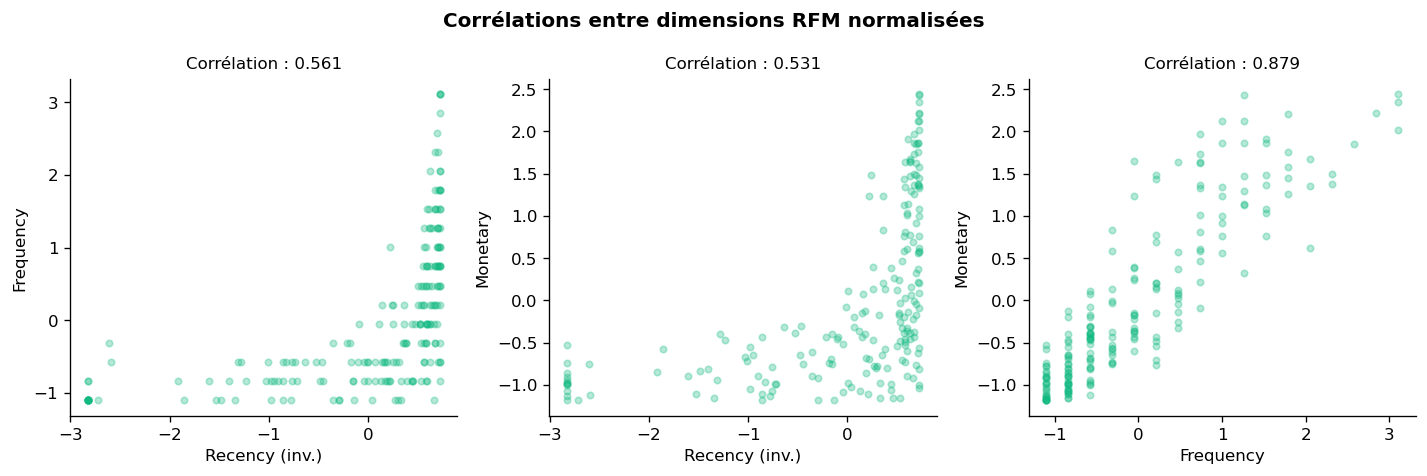

In [14]:
# Préparation des features
features = pd.DataFrame({
    "R": -df_rfm_clean['recency'], # inversé : récent = grand = bon
    "F": df_rfm_clean['frequency'],
    "M": df_rfm_clean['monetary'],
}, index=df_rfm_clean.index)

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print("Features normalisées — statistiques :")
print(pd.DataFrame(X_scaled, columns=["R_scaled", "F_scaled", "M_scaled"]).describe().round(4))

norm_cols = ["R_scaled", "F_scaled", "M_scaled"]
X_df = pd.DataFrame(X_scaled, columns=norm_cols)

# Vérification corrélation RFM
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
pairs = [('R_scaled','F_scaled'), ('R_scaled','M_scaled'), ('F_scaled','M_scaled')]
labels = [('Recency (inv.)', 'Frequency'), ('Recency (inv.)', 'Monetary'), ('Frequency', 'Monetary')]

for ax, (x, y), (xl, yl) in zip(axes, pairs, labels):
    ax.scatter(X_df[x], X_df[y], alpha=0.3, s=15, color=PALETTE[1])
    ax.set_xlabel(xl, fontsize=10); ax.set_ylabel(yl, fontsize=10)
    corr = X_df[x].corr(X_df[y])
    ax.set_title(f'Corrélation : {corr:.3f}', fontsize=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.suptitle('Corrélations entre dimensions RFM normalisées', fontsize=12, fontweight='bold')
plt.tight_layout()
os.makedirs("plots_s4", exist_ok=True)
plt.savefig('plots_s4/rfm_correlations.png', dpi=120, bbox_inches='tight')
plt.close()

display(Image("plots_s4/rfm_correlations.png"))

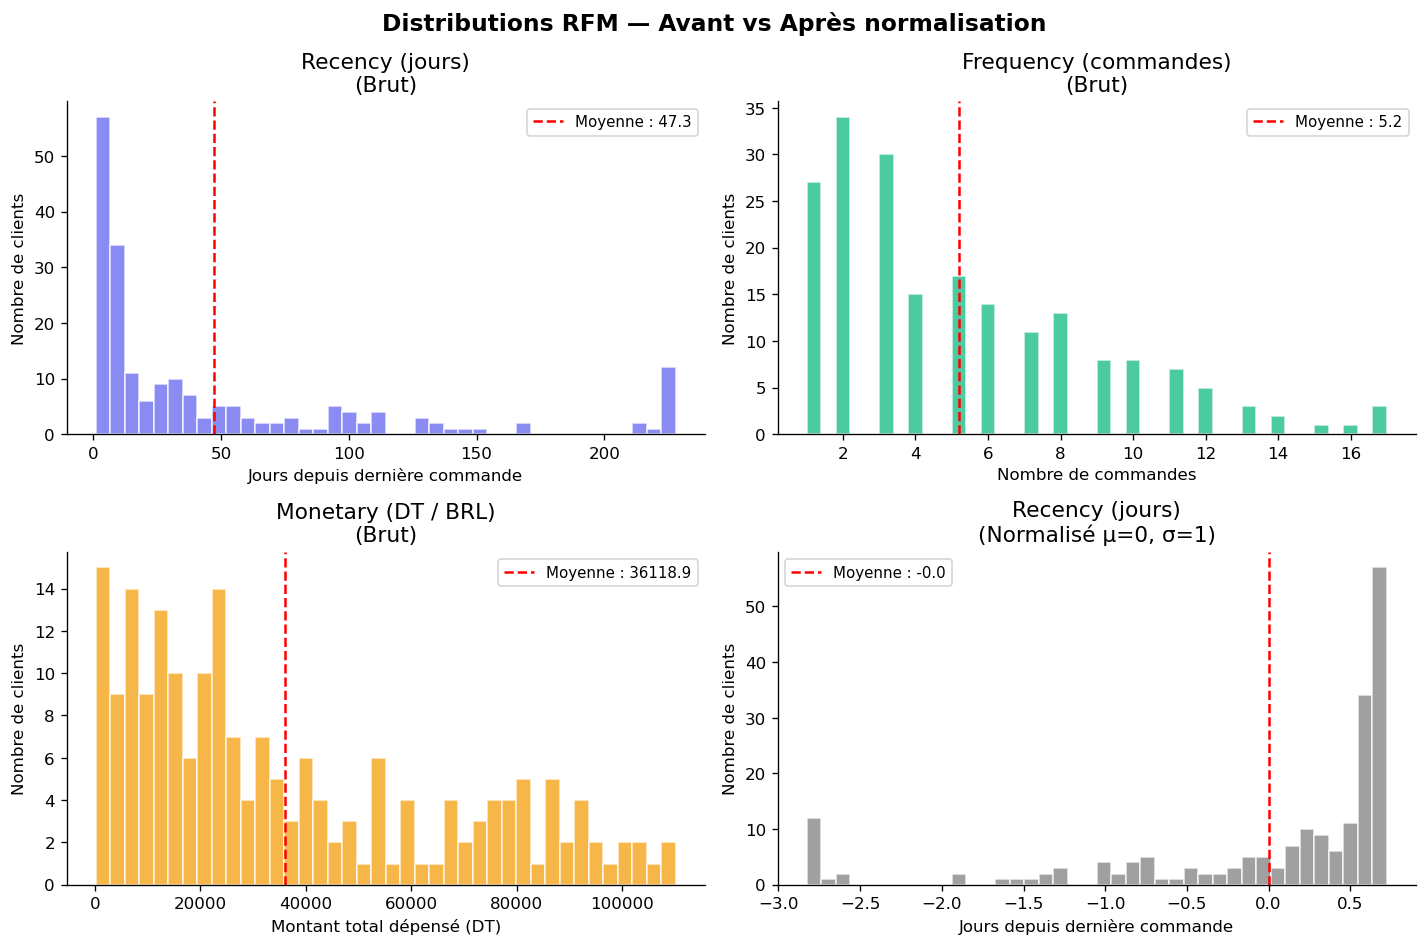

In [15]:
# Visualisation avant / après normalisation
# Grille 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

fig.suptitle("Distributions RFM — Avant vs Après normalisation", fontsize=14, fontweight="bold")

raw_info = [
    ("recency", "Recency (jours)", "Jours depuis dernière commande"),
    ("frequency", "Frequency (commandes)", "Nombre de commandes"),
    ("monetary", "Monetary (DT / BRL)", "Montant total dépensé (DT)"),
]

colors = PALETTE[:3]
# Boucle pour les 3 distributions brutes
for j, ((rcol, rbl, xlabel), ncol, col) in enumerate(zip(raw_info, norm_cols, colors)):
    axes[j].hist(df_rfm_clean[rcol], bins=40, color=col, alpha=0.75, edgecolor="white")
    axes[j].set_title(f"{rbl}\n(Brut)")
    axes[j].set_xlabel(xlabel, fontsize=10)
    axes[j].set_ylabel('Nombre de clients', fontsize=10)

    mean_val = df_rfm_clean[rcol].mean()
    axes[j].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Moyenne : {mean_val:.1f}')
    axes[j].legend(fontsize=9)
    axes[j].spines['top'].set_visible(False)
    axes[j].spines['right'].set_visible(False)

# 4e case : distribution normalisée de Recency
axes[3].hist(X_df["R_scaled"], bins=40, color="gray", alpha=0.75, edgecolor="white")
axes[3].set_title("Recency (jours)\n(Normalisé µ=0, σ=1)")
axes[3].set_xlabel(raw_info[0][2], fontsize=10)
axes[3].set_ylabel('Nombre de clients', fontsize=10)
mean_val = X_df["R_scaled"].mean()
axes[3].axvline(mean_val, color='red', linestyle='--', linewidth=1.5, label=f'Moyenne : {mean_val:.1f}')
axes[3].legend(fontsize=9)
axes[3].spines['top'].set_visible(False)
axes[3].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("plots_s4/distribution_rfm.png", dpi=120, bbox_inches="tight")
plt.close()

display(Image("plots_s4/distribution_rfm.png"))

<a name="6"></a>
## 6 - Selection de K optimal — Elbow + Silhouette + Davies-Bouldin

| **Métrique** | **Définition** | **Chercher** |
|--------------|----------------|--------------|
| **Inertie (Elbow)** | Somme des distances carrées intra-cluster | Le *coude* — rendement décroissant |
| **Silhouette** | Cohésion intra / séparation inter | Maximum (proche + 1 = bien séparé) |
| **Davies-Bouldin** | Radio distance intra / inter | Minimum (compact et bien séparé |

   K      Inertie   Silhouette Davies-Bouldin
--------------------------------------------------
 K= 2        270.8       0.4828         0.7509
 K= 3        139.9       0.4955         0.6824
 K= 4         99.8       0.4238         0.7517
 K= 5         76.8       0.4103         0.7341
 K= 6         59.2       0.3993         0.8186
 K= 7         51.4       0.3913         0.8378
 K= 8         45.6       0.3852         0.8480
 K= 9         38.7       0.3904         0.8226
 K=10         35.7       0.3776         0.8478


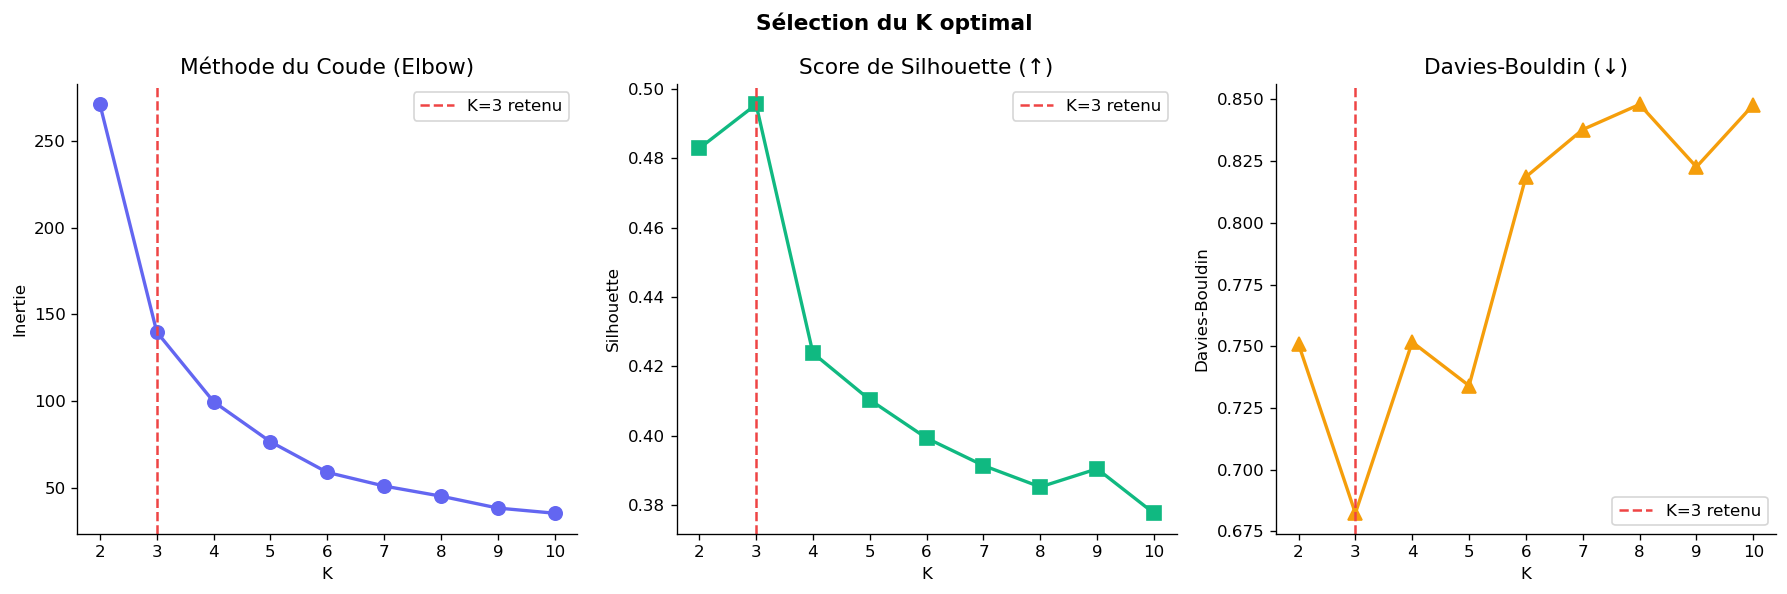


Meilleur K (Silhouette) : K=3

Meilleur K (Davies-Bouldin) : K=3


In [16]:
# Calcul des métriques pour k ← 2 à 10
K_RANGE = range(2, 11)
inertias = []
sil_scores = []
db_scores = []

print(f"{'K':>4} {'Inertie':>12} {'Silhouette':>12} {'Davies-Bouldin':>14}")
print("-" * 50)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=min(5000, len(X_scaled)))
    db = davies_bouldin_score(X_scaled, labels)

    inertias.append(km.inertia_)
    sil_scores.append(sil)
    db_scores.append(db)
    print(f" K={k:2d} {km.inertia_:12.1f} {sil:12.4f} {db:14.4f}")

# Visualisation
ks = list(K_RANGE)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Sélection du K optimal", fontsize=13, fontweight="bold")

axes[0].plot(ks, inertias, "o-", color=PALETTE[0], lw=2, ms=8)
axes[0].axvline(3, color=PALETTE[3], ls="--", lw=1.5, label="K=3 retenu")
axes[0].set(xlabel="K", ylabel="Inertie", title="Méthode du Coude (Elbow)")
axes[0].legend()
axes[0].set_xticks(ks)

axes[1].plot(ks, sil_scores, "s-", color=PALETTE[1], lw=2, ms=8)
axes[1].axvline(3, color=PALETTE[3], ls="--", lw=1.5, label="K=3 retenu")
axes[1].set(xlabel="K", ylabel="Silhouette", title="Score de Silhouette (↑)")
axes[1].legend()
axes[1].set_xticks(ks)

axes[2].plot(ks, db_scores, "^-", color=PALETTE[2], lw=2, ms=8)
axes[2].axvline(3, color=PALETTE[3], ls="--", lw=1.5, label="K=3 retenu")
axes[2].set(xlabel="K", ylabel="Davies-Bouldin", title="Davies-Bouldin (↓)")
axes[2].legend()
axes[2].set_xticks(ks)

plt.tight_layout()
plt.savefig("plots_s4/k_optimal.png", dpi=120, bbox_inches="tight")
plt.close()

display(Image("plots_s4/k_optimal.png"))

best_sil_k = ks[int(np.argmax(sil_scores))]
best_db_k = ks[int(np.argmin(db_scores))]
print(f"\nMeilleur K (Silhouette) : K={best_sil_k}")
print(f"\nMeilleur K (Davies-Bouldin) : K={best_db_k}")

<a name="7"></a>
## 7 - Entraînement k-Means final (K=3)

### Paramètres clés :

- `init="k-means++`: initialisation intelligente pour maximiser la distance initiale entre les centroïdes afin d'éviter les minima locaux.
- `n_init=20`: 20 exécutions indépendantes et puis on retient la meilleure.
- `algorithm="lloyd"`: algorithme EM standard (Expectation-Maximization itératif)


In [17]:
# Entraînement K-Means avec le K optimal
K_OPTIMAL = 3
kmeans = KMeans(
    n_clusters=K_OPTIMAL,
    init="k-means++",
    n_init=20,
    max_iter=300,
    random_state=RANDOM_STATE,
    algorithm="lloyd",
)
kmeans.fit(X_scaled)
cluster_labels = kmeans.labels_

# Métriques
final_sil = silhouette_score(X_scaled, cluster_labels, sample_size=min(5000, len(X_scaled)))
final_db = davies_bouldin_score(X_scaled, cluster_labels)

print("=" * 55)
print(f"K-Means entraîné — K={K_OPTIMAL}")
print(f"  Inertie finale : {kmeans.inertia_:,.1f}")
print(f"  Score de Silhouette : {final_sil:4.4f} (> 0.35 = acceptable)")
print(f"  Score Davies-Bouldin : {final_db:4.4f} (< 1.5 = bon)")
print(f"  Itérations : {kmeans.n_iter_}")
print("=" * 55)

df_rfm_clean["cluster_raw"] = cluster_labels

K-Means entraîné — K=3
  Inertie finale : 139.9
  Score de Silhouette : 0.4955 (> 0.35 = acceptable)
  Score Davies-Bouldin : 0.6824 (< 1.5 = bon)
  Itérations : 10


In [18]:
# ==== Labels & couleurs des 4 segments =====================================================
SEGMENT_LABELS = {
    0: "Champions",
    1: "Loyaux",
    2: "À risque / Perdus",
}

SEGMENT_NAMES = {
    0: "champions",
    1: "Loyaux",
    2: "a_risque_perdus",
}
SEGMENT_COLORS = {
    0: "#10B981",  # vert
    1: "#3B82F6",  # bleu
    2: "#F59E0B",  # orange
}
SEGMENT_ACTIONS = {
    0: "Programme VIP, early access nouveautés, récompenses exclusives",
    1: "Newsletter personnalisée, offres fidélité, corss-sell",
    2: "Campagne réactivation — remise (exp : 15-20%) — email : 'Vous nous manquez'",
}

In [19]:
# Réordonnancement sémaantique des cluster

# K-Means assigne les labels abitrairement (0,1,2,3).
# On les réordonne par Monetary moyen décroissant tout en attribuant des labels bussness

stats_raw = df_rfm_clean.groupby("cluster_raw").agg(
    n = ("cluster_raw", "count"),
    R_mean = ("recency", "mean"),
    F_mean = ("frequency", "mean"),
    M_mean = ("monetary", "mean"),
).round(2)

order_by_m = stats_raw["M_mean"].sort_values(ascending=False).index.tolist()
remap = {raw_k: new_k for new_k, raw_k in enumerate(order_by_m)}
print("Mapping (cluster_raw → cluster_final) :", remap)

df_rfm_clean["cluster"] = df_rfm_clean["cluster_raw"].map(remap)
df_rfm_clean["segment"] = df_rfm_clean["cluster"].map(SEGMENT_NAMES)
df_rfm_clean["segment_label"] = df_rfm_clean["cluster"].map(SEGMENT_LABELS)

# Statistiques finales
cluster_stats = df_rfm_clean.groupby("cluster").agg(
    segment_label = ("segment_label", "first"),
    n_clients = ("cluster", "count"),
    recency_avg = ("recency", "mean"),
    frequency_avg = ("frequency", "mean"),
    monetary_avg = ("monetary", "mean"),
    monetary_total = ("monetary", "sum"),
).round(2)

total_rev = cluster_stats["monetary_total"].sum()
total_cli = cluster_stats["n_clients"].sum()
cluster_stats["pct_clients"] = (cluster_stats["n_clients"] / total_cli * 100).round(1)
cluster_stats["pct_revenue"] = (cluster_stats["monetary_total"] / total_rev * 100).round(1)

print("\nSegments clients — Smartshop")
print("=" * 80)
for i, row in cluster_stats.iterrows():
    print(f"  {str(row['segment_label']):<25} {int(row['n_clients']):5,} clients"
          f"  ({row['pct_clients']:.1f}%) R={row['recency_avg']:.0f}j"
          f"  F={row['frequency_avg']:.1f} M={row['monetary_avg']:.0f} CA={row['pct_revenue']:.1f}%")
print("=" * 80)


Mapping (cluster_raw → cluster_final) : {2: 0, 0: 1, 1: 2}

Segments clients — Smartshop
  Champions                    58 clients  (29.1%) R=6j  F=10.0 M=77780 CA=62.8%
  Loyaux                      101 clients  (50.8%) R=27j  F=3.8 M=22892 CA=32.2%
  À risque / Perdus            40 clients  (20.1%) R=159j  F=1.8 M=9108 CA=5.1%


<a name="8"></a>
## 8 - Analyse & visualisation des clusters

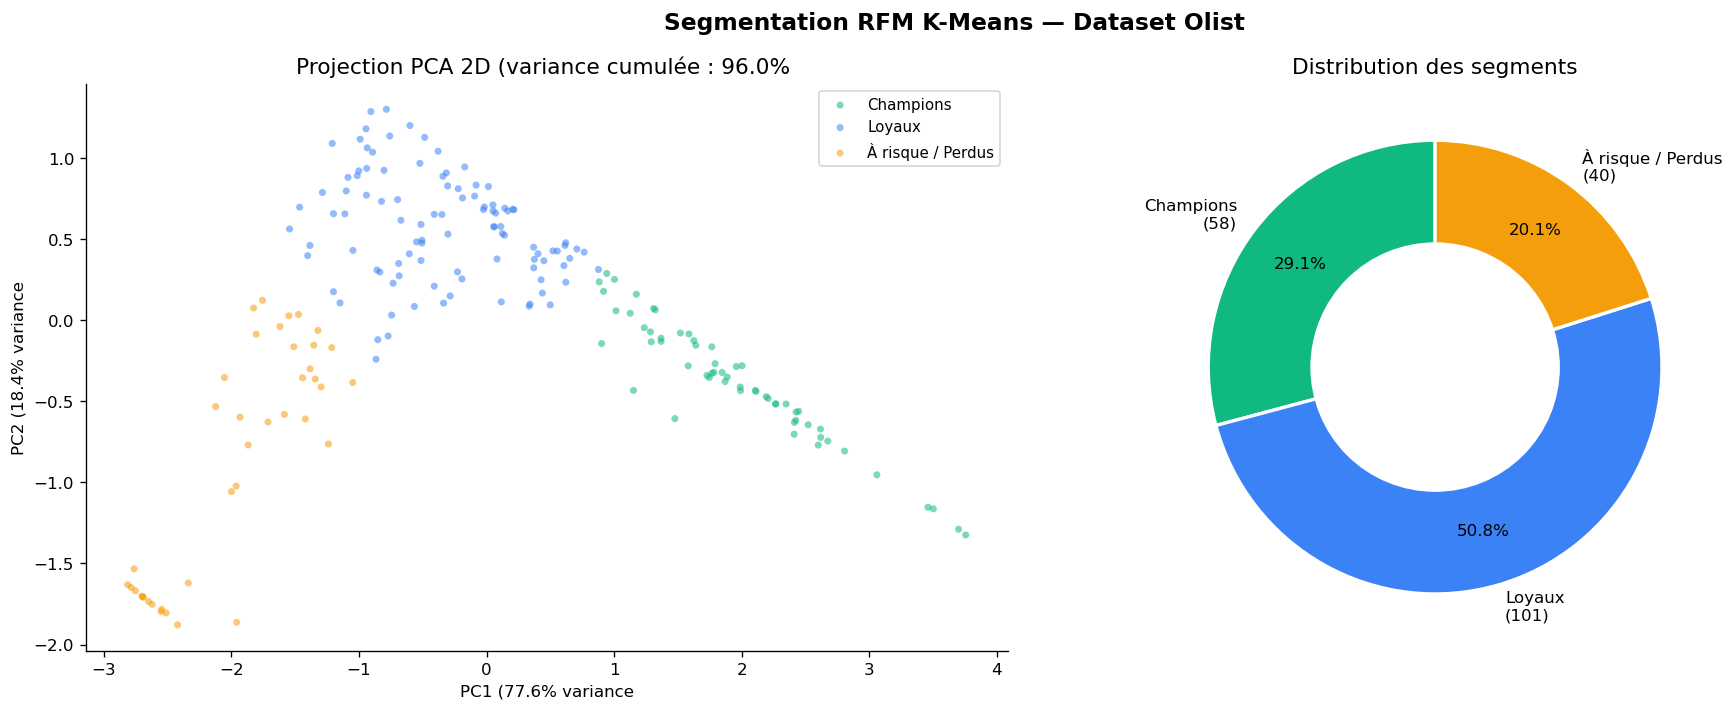

In [20]:
# PCA 2D + Donut distribution
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_

df_pca = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": df_rfm_clean["cluster"],
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Segmentation RFM K-Means — Dataset Olist", fontsize=14, fontweight="bold")

# Scatter PCA
for c in range(K_OPTIMAL):
    mask = df_pca["cluster"] == c
    axes[0].scatter(
        df_pca.loc[mask, "PC1"], df_pca.loc[mask, "PC2"],
        c=SEGMENT_COLORS[c], s=18, alpha=0.55,
        label=SEGMENT_LABELS[c], edgecolors="none"
    )
axes[0].set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% variance")
axes[0].set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% variance")
axes[0].set_title(f"Projection PCA 2D (variance cumulée : {sum(var_explained)*100:.1f}% ")
axes[0].legend(loc="upper right", fontsize=9)

# Donut
sizes = cluster_stats["n_clients"].values
clrs = [SEGMENT_COLORS[i] for i in range(K_OPTIMAL)]
lbls = [f"{SEGMENT_LABELS[i]}\n({int(cluster_stats.loc[i,'n_clients'])})" for i in range(K_OPTIMAL)]
wedges, _, autotexts = axes[1].pie(sizes, labels=lbls, autopct="%1.1f%%", colors=clrs,startangle=90, 
                                   pctdistance=0.75, wedgeprops={"edgecolor":"white", "linewidth":2}
                                  )
for at in autotexts:
    at.set_fontsize(10)
axes[1].add_patch(plt.Circle((0, 0), 0.55,  fc="white"))
axes[1].set_title("Distribution des segments")

plt.tight_layout()
plt.savefig("plots_s4/pca_2d&distribution_donut.png", dpi=120, bbox_inches="tight")
plt.close()

display(Image("plots_s4/pca_2d&distribution_donut.png"))

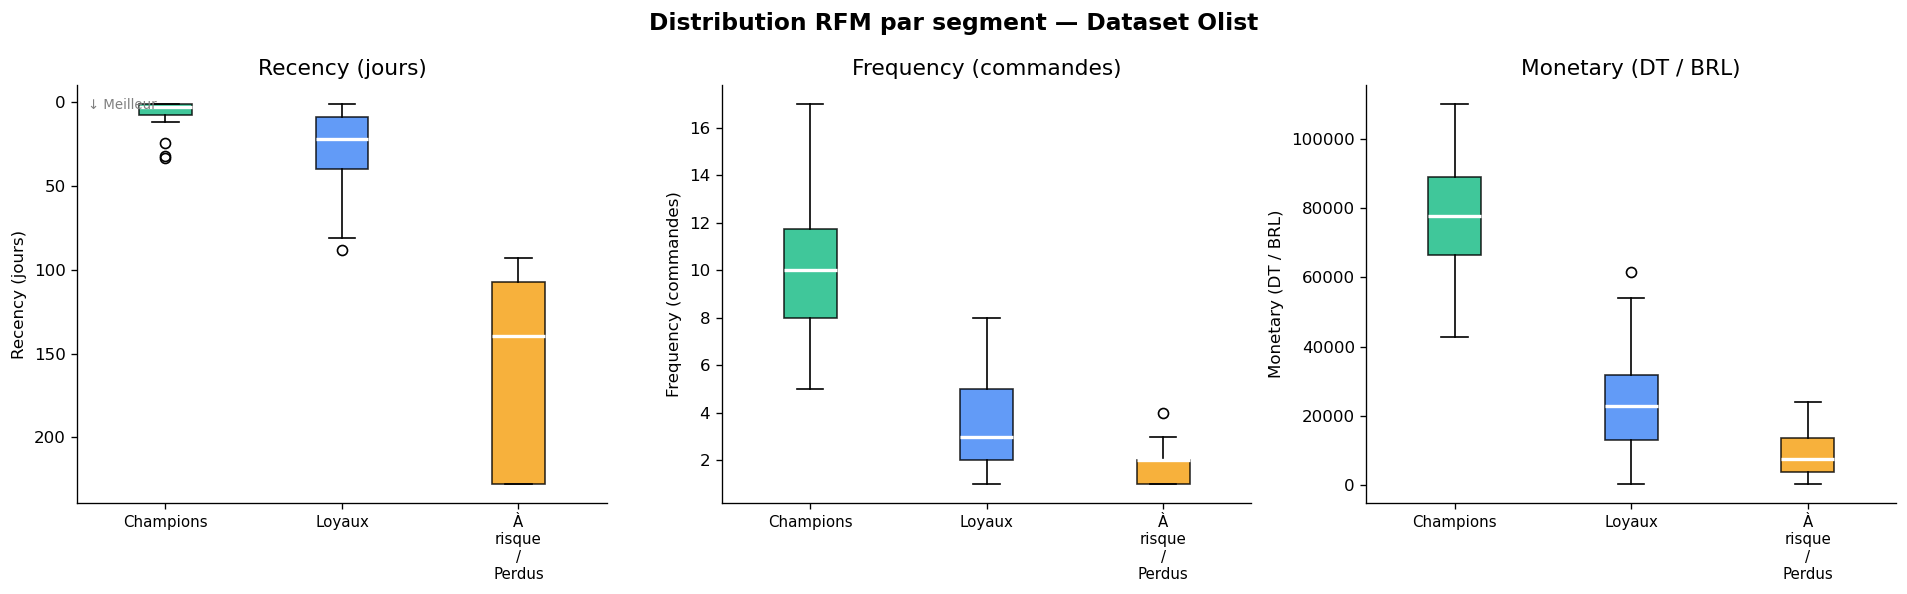

In [21]:
# Boxplots RFM segment
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribution RFM par segment — Dataset Olist", fontsize=14, fontweight="bold")

rfm_info = [
    ("recency", "Recency (jours)", True),
    ("frequency", "Frequency (commandes)", False),
    ("monetary", "Monetary (DT / BRL)", False),
]

for ax, (col, ylabel, invert) in zip(axes, rfm_info):
    data = [df_rfm_clean.loc[df_rfm_clean["cluster"]==i, col].values for i in range(K_OPTIMAL)]
    bp = ax.boxplot(data, patch_artist=True, medianprops={"color": "white", "linewidth":2})
    for patch, c in zip(bp["boxes"], range(K_OPTIMAL)):
        patch.set_facecolor(SEGMENT_COLORS[c])
        patch.set_alpha(0.8)
    ax.set_xticklabels([SEGMENT_LABELS[i].replace(" ", "\n") for i in range(K_OPTIMAL)], fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    if invert:
        ax.invert_yaxis()
        ax.text(0.02, 0.97, "↓ Meilleur", transform=ax.transAxes, fontsize=8, va="top", color="gray")
plt.tight_layout()
plt.savefig("plots_s4/distribution_rfm_segment.png", dpi=120, bbox_inches="tight")
plt.close()

display(Image("plots_s4/distribution_rfm_segment.png"))

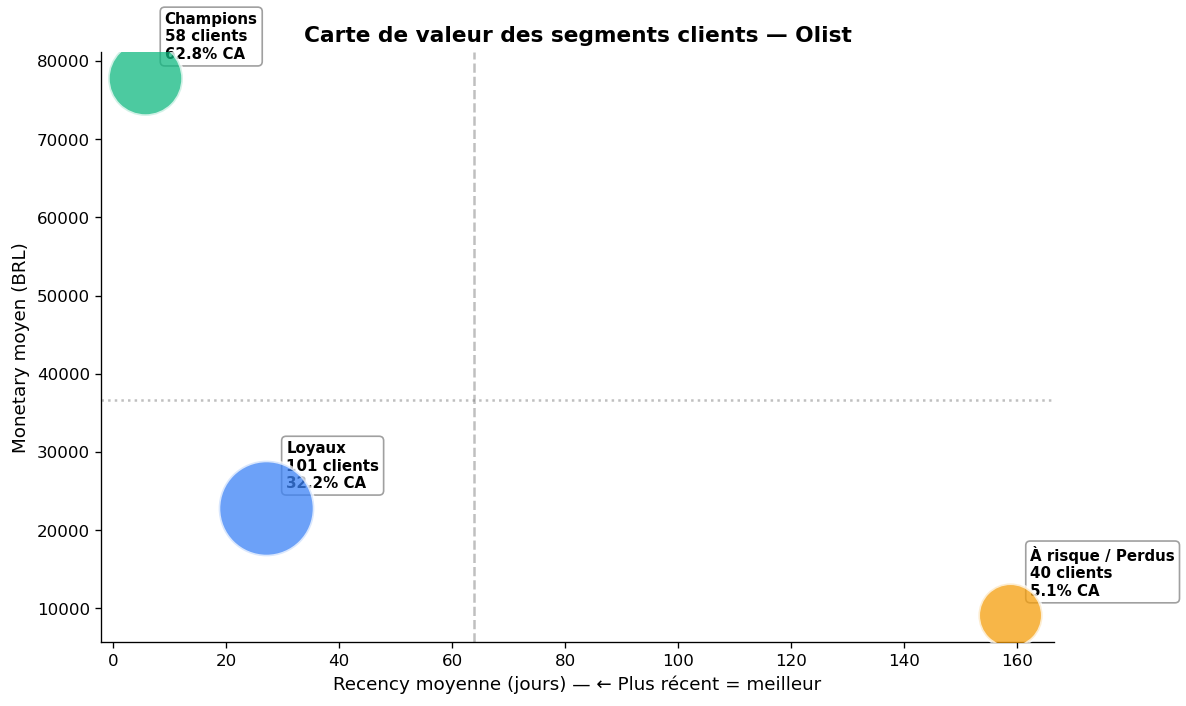

In [22]:
# Bubble Chart : Recency vs Monetary, taille = % clients
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title("Carte de valeur des segments clients — Olist", fontsize=13, fontweight="bold")

for i, row in cluster_stats.iterrows():
    sz = (row["pct_clients"] / cluster_stats["pct_clients"].max()) * 3000 + 300
    ax.scatter(row["recency_avg"], row["monetary_avg"], s=sz,
               c=SEGMENT_COLORS[i], alpha=0.75, edgecolors="white", linewidths=2, zorder=5)
    ax.annotate(
        f"{SEGMENT_LABELS[i]}\n{int(row['n_clients']):,} clients\n{row['pct_revenue']}% CA",
        xy=(row["recency_avg"], row["monetary_avg"]),
        xytext=(12, 12), textcoords="offset points", fontsize=9, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.75, edgecolor="gray"),
    )

ax.axvline(cluster_stats["recency_avg"].mean(),  color="gray", ls="--", alpha=0.5)
ax.axhline(cluster_stats["monetary_avg"].mean(), color="gray", ls=":",  alpha=0.5)
ax.set_xlabel("Recency moyenne (jours) — ← Plus récent = meilleur", fontsize=11)
ax.set_ylabel("Monetary moyen (BRL)", fontsize=11)

plt.tight_layout()
plt.savefig("plots_s4/carte_valeur_segment.png", dpi=120, bbox_inches="tight")
plt.close()

display(Image("plots_s4/carte_valeur_segment.png"))

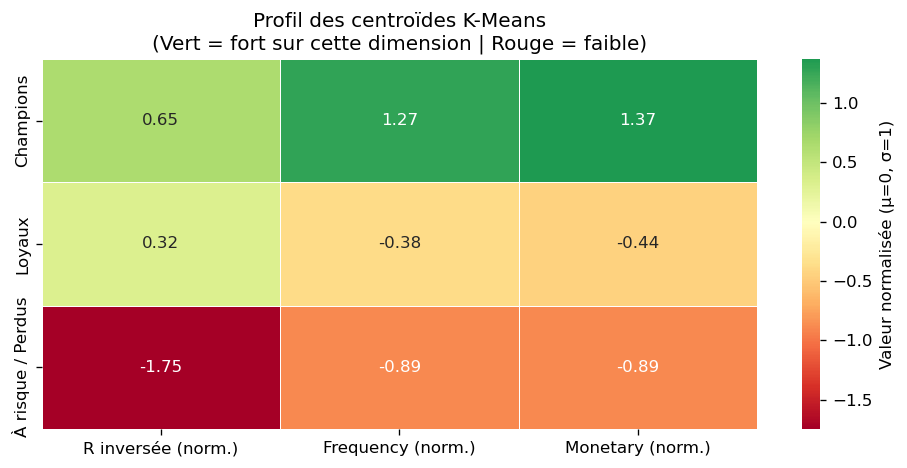


Lecture de la heatmap :
  Champions : toutes les valeurs vertes → excellent sur R, F, M
  Perdus    : toutes les valeurs rouges → faible sur R, F, M


In [23]:
# Heatmap des centroïdes normalisés 
#   Montre le "profil type" de chaque segment dans l'espace normalisé.
#   Vert = élevé sur cette dimension = bon client.

inv_remap = {v: k for k, v in remap.items()}
centroids_ordered = np.array([kmeans.cluster_centers_[inv_remap[i]] for i in range(K_OPTIMAL)])

df_centr = pd.DataFrame(
    centroids_ordered,
    columns=["R inversée (norm.)", "Frequency (norm.)", "Monetary (norm.)"],
    index=[SEGMENT_LABELS[i] for i in range(K_OPTIMAL)]
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df_centr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Valeur normalisée (µ=0, σ=1)"})
ax.set_title("Profil des centroïdes K-Means\n"
             "(Vert = fort sur cette dimension | Rouge = faible)", fontsize=12)

plt.tight_layout()
plt.savefig("plots_s4/carte_valeur_segment.png", dpi=120, bbox_inches="tight")
plt.close()

display(Image("plots_s4/carte_valeur_segment.png"))

print("\nLecture de la heatmap :")
print("  Champions : toutes les valeurs vertes → excellent sur R, F, M")
print("  Perdus    : toutes les valeurs rouges → faible sur R, F, M")


<a name="9"></a>
## 9 - Insights métier & Actions CRM

In [24]:
# Sysnthèse métier
print("=" * 90)
print("SYNTHÈSE SEGMENTATION CLIENTS — OLIST")
print("=" * 90)

for i in range(K_OPTIMAL):
    row = cluster_stats.loc[i]
    print(f"\n{SEGMENT_LABELS[i]}")
    print(f"  Clients : {int(row['n_clients']):,} ({row['pct_clients']:.1f}%)")
    print(f"  Recency : {row['recency_avg']:.0f} jours en moyenne")
    print(f"  Frequency : {row['frequency_avg']:.1f} commandes en moyenne")
    print(f"  Monetary : {row['monetary_avg']:.0f} BRL ({row['pct_revenue']:.1f}% du CA)")
    print(f"  Action : {SEGMENT_ACTIONS[i]}")

    # Roi estimé campagne réactivation
    n_at_risk = int(cluster_stats.loc[2, "n_clients"])
    m_avg = float(cluster_stats.loc[2, "monetary_avg"])
    print(f"\nRoi estimé - Campagne réactivation 'À risque' :")
    print(f"  {n_at_risk:,} clients ciblés | panier moyen : {m_avg:.0f} BRL")
    print(f"  Si 10% se réactivent → {n_at_risk*0.1*m_avg:,.0f} BRL CA additionnel")
    print(f"  Si 20% se réactivent → {n_at_risk*0.2*m_avg:,.0f} BRL CA additionnel")

SYNTHÈSE SEGMENTATION CLIENTS — OLIST

Champions
  Clients : 58 (29.1%)
  Recency : 6 jours en moyenne
  Frequency : 10.0 commandes en moyenne
  Monetary : 77780 BRL (62.8% du CA)
  Action : Programme VIP, early access nouveautés, récompenses exclusives

Roi estimé - Campagne réactivation 'À risque' :
  40 clients ciblés | panier moyen : 9108 BRL
  Si 10% se réactivent → 36,432 BRL CA additionnel
  Si 20% se réactivent → 72,864 BRL CA additionnel

Loyaux
  Clients : 101 (50.8%)
  Recency : 27 jours en moyenne
  Frequency : 3.8 commandes en moyenne
  Monetary : 22892 BRL (32.2% du CA)
  Action : Newsletter personnalisée, offres fidélité, corss-sell

Roi estimé - Campagne réactivation 'À risque' :
  40 clients ciblés | panier moyen : 9108 BRL
  Si 10% se réactivent → 36,432 BRL CA additionnel
  Si 20% se réactivent → 72,864 BRL CA additionnel

À risque / Perdus
  Clients : 40 (20.1%)
  Recency : 159 jours en moyenne
  Frequency : 1.8 commandes en moyenne
  Monetary : 9108 BRL (5.1% du CA

<a name="10"></a>
## 10 - Sauvegarde des artefacts ML (.pkl)

| Fichier | Contenu | Utilisé par FastAPI |
|---------|---------|---------------------|
| `kmeans_rfm.pkl` | Modèle K-Means | `predict_segment()` |
| `rfm_scaler.pkl` | StandardScaler | `predict_segment()` |
| `rfm_meta.pkl` | Paramètres (K, remap, labels) | Tous les endpoints |
| `rfm_cluster_stats.pkl` | Statistiques par cluster | `/ml/segments-stats` |


In [25]:
# ── Répertoire des modèles ──────────────────────────────────────────────────
import joblib
# MODELS_DIR = Path(os.getenv('MODELS_DIR', '/shared/ml_models'))
MODELS_DIR = Path('./models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_SUFFIX = 'smartshop' if USE_SMARTSHOP else 'kaggle'
MODEL_VERSION = 'kmeans_' + MODEL_SUFFIX + '_v1_k' + str(K_OPTIMAL)

# 1. K-Means
joblib.dump(kmeans, MODELS_DIR / "kmeans_rfm.pkl")

## 2. Scaler
joblib.dump(scaler, MODELS_DIR / "rfm_scaler.pkl")

## 3. Métadonnées
model_meta = {
    "model_version": MODEL_VERSION,
    'data_source': DATA_SOURCE,
    "k": K_OPTIMAL,
    "feature_names": ["R_inverted", "F", "M"],
    "cluster_labels": SEGMENT_LABELS,
    "cluster_names": SEGMENT_NAMES,
    "cluster_actions": SEGMENT_ACTIONS,
    "cluster_colors": {str(k): v for k, v in SEGMENT_COLORS.items()},
    "remap": {str(k): v for k, v in remap.items()},
    "silhouette": round(final_sil, 4),
    "davies_bouldin": round(final_db, 4),
    "inertia": round(kmeans.inertia_, 2),
    "trained_at": datetime.now().isoformat(),
    "n_train_samples": len(X_scaled),
    "random_state": RANDOM_STATE,
}
joblib.dump(model_meta, MODELS_DIR / "rfm_meta.pkl")

## 4. Statistiques cluster
joblib.dump(cluster_stats.reset_index().to_dict(orient="records"), MODELS_DIR / "rfm_cluster_stats.pkl")

## Fichiers créés
print(f"\n{MODELS_DIR} :")
for f in sorted(MODELS_DIR.glob("*.pkl")):
    if "rfm" in f.name:
        print(f"  {f.name:<30s} {f.stat().st_size/1024:6.1f} KB")
    
print(f'   Source : {DATA_SOURCE} | K={K_OPTIMAL} | Clients={len(df_rfm_clean):,}')
print()
print(f'Silhouette SmartShop : {final_sil:.4f}')
print(f'N clients train      : {len(X_scaled)} à {datetime.now().isoformat()}')




models :
  kmeans_rfm.pkl                    1.6 KB
  rfm_cluster_stats.pkl             0.4 KB
  rfm_meta.pkl                      0.7 KB
  rfm_scaler.pkl                    0.9 KB
   Source : SmartShop | K=3 | Clients=199

Silhouette SmartShop : 0.4955
N clients train      : 199 à 2026-05-29T01:44:06.791732
